In [16]:
import pytz
from datetime import datetime
from dateutil.relativedelta import relativedelta
from skyfield.api import load, wgs84, EarthSatellite
import numpy as np

## Standard satellite TLE query

In [2]:
# # Download satellite TLE data from NORAD
# stations_url = 'https://www.celestrak.com/NORAD/elements/stations.txt'
# satellites = load.tle_file(stations_url)
# by_name = {sat.name: sat for sat in satellites}

In [3]:
# ts = load.timescale()
# # satellite = EarthSatellite(line1, line2, 'HST', ts)
# satellite=by_name['ISS (NAUKA)']
# print(satellite)

# # Get the current time in a timezone-aware fashion.

# tz = pytz.timezone('UTC')
# dt = tz.localize(datetime.utcnow())
# print(f"Exectution time: {dt:%Y-%m-%d %H:%M:%S %Z}\n")

# # Split the next 200 minutes into a collection of 101-evenly
# # spaced Timescales (every two minutes, plus endpoints)

# t0 = ts.utc(dt)
# t1 = ts.utc(dt + relativedelta(minutes=100))
# timescales = ts.linspace(t0, t1, 1000)

# # calculate the subpoints.

# geocentrics = satellite.at(timescales)
# points= wgs84.subpoint_of(geocentrics)

In [4]:
# longitude=(points.longitude.degrees)
# latitude=(points.latitude.degrees)
# print(f'Altitude is {wgs84.height_of(satellite.at(t0)).km}')

In [5]:
# from src2.shapecheck import shapecheck
# shapecheck(longitude,latitude,'')

## Customize satellite with self defined orbital elements

In [61]:
ts = load.timescale()

line1='1 25544U 98067A   98329.57169160 -.00146458  00000-0 -18619-2 0   398'
line2='2 25544  51.5964 140.8358 0009347 223.7905 136.2350 15.59090576   841'
satellite = EarthSatellite(line1, line2, 'Landsat-8', ts)
print(satellite)

# Get the current time in a timezone-aware fashion.

tz = pytz.timezone('UTC')
dt = tz.localize(datetime.utcnow())
print(f"Exectution time: {dt:%Y-%m-%d %H:%M:%S %Z}\n")

# Split the next 200 minutes into a collection of 101-evenly
# spaced Timescales (every two minutes, plus endpoints)

t0 = ts.utc(dt)
t1 = ts.utc(dt + relativedelta(minutes=10))
timescales = ts.linspace(t0, t1, 100)

# calculate the subpoints.

geocentrics = satellite.at(timescales)

subpoints = wgs84.subpoint_of(geocentrics)
altitude=satellite.epoch.utc
print(altitude)

Landsat-8 catalog #25544 epoch 1998-11-25 13:43:14 UTC
Exectution time: 2024-03-07 12:21:42 UTC

CalendarTuple(year=1998, month=11, day=25, hour=13, minute=43, second=14.154266357421875)


In [62]:
finvel=np.sqrt((geocentrics.velocity.km_per_s[0])**2+(geocentrics.velocity.km_per_s[1])**2+(geocentrics.velocity.km_per_s[2])**2)

In [63]:
epoch=(t0.astimezone(tz))
print(f"epoch : {epoch:%Y-%m-%d %H:%M:%S %Z}\n")

epoch : 2024-03-07 12:21:42 UTC



In [64]:
# 2024-02-26 03:17:08

In [65]:
Lon,Lat=subpoints.longitude.degrees,subpoints.latitude.degrees

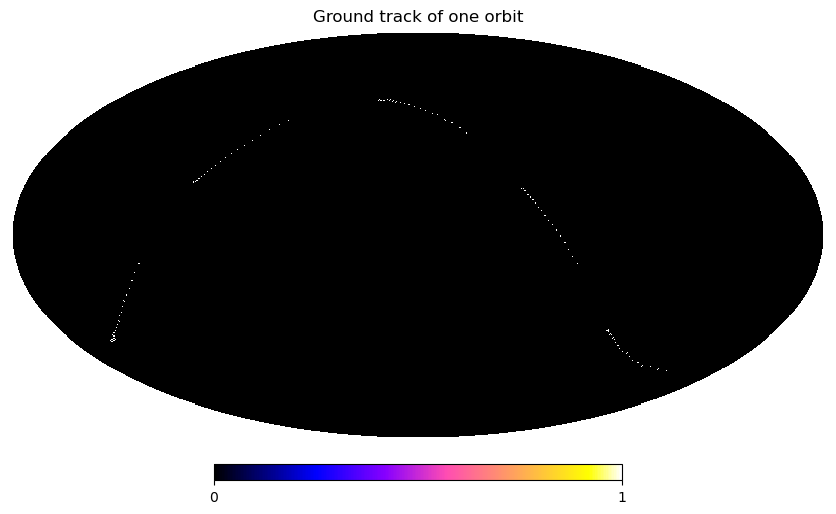

In [66]:
from src2.shapecheck import shapecheck
shapecheck(Lon,Lat,'Ground track of one orbit')
# plt.savefig('/home/pratush/Yogen_STARFIRE/STARFIRE_paper_images/GT.pdf',dpi=600,bbox_inches='tight')


In [13]:
# import pandas as pd
# df=pd.DataFrame({'Lon':Lon,'Lat':Lat})
# df.to_csv('/home/pratush/Desktop/neworbit.csv')

In [14]:
Lon[0],Lat[0]

(168.70577855871505, 63.164920397169375)

In [ ]:
sunlit=geocentrics.is_sunlit(eph)
timescales.utc[5,2]-timescales.utc[5,1]